In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix,precision_score,recall_score

In [5]:
trans=pd.read_csv("/home/mr-vaani/Downloads/transactions_null.csv")
# Importing the csv document into 

In [6]:
trans.head()
## having a quick overview of the project
## looking at the daata threer is type of transactions , the total amount of transaction  name of the origin person who initiated the transaction 
## old and new balance of the sender 
## Destination name , destination balance for new and old
## IsFraud as the target


,step,type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [7]:
trans.info()

## looking at the dataset info  3 attributes are non numerical

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            999999 non-null  int64  
 1   type            999999 non-null  object 
 2   amount          999984 non-null  float64
 3   nameOrig        999999 non-null  object 
 4   oldbalanceOrig  999999 non-null  float64
 5   newbalanceOrig  999999 non-null  float64
 6   nameDest        999999 non-null  object 
 7   oldbalanceDest  999999 non-null  float64
 8   newbalanceDest  999999 non-null  float64
 9   isFraud         999999 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 76.3+ MB


In [8]:
#checking the categories for each objects
trans["type"].value_counts()

type
CASH_OUT    362676
PAYMENT     329752
CASH_IN     218673
TRANSFER     82424
DEBIT         6474
Name: count, dtype: int64

In [9]:
trans["nameOrig"].value_counts()

nameOrig
C1647276567    2
C1738972765    2
C228527000     2
C1561789477    2
C918584437     2
              ..
C2046151928    1
C617154211     1
C1355574122    1
C118091655     1
C1278734045    1
Name: count, Length: 999758, dtype: int64

In [10]:
trans["nameDest"].value_counts()

nameDest
C985934102     96
C1286084959    96
C248609774     88
C1590550415    88
C665576141     87
               ..
M494188229      1
M1323690807     1
M1834276991     1
M1171669554     1
M399751935      1
Name: count, Length: 422895, dtype: int64

In [11]:
# now lets look at the summary of all numerical attributes

trans.describe()

##looking at our numrical values we get the percentile values taking an example  25% of the Fraud are 0 Meaning the did not occur 50% of the steps are bellow 20
## We also get see other data such as the mean  now looking at the standard deviation   being larger for some values , i am predicting that there is a small posibility of an outlier 
## Since the datas most of the datas have not deviated so much from the mean
## But lets plot the data so that we could prove everything by ourselves

,step,amount,oldbalanceOrig,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,999999.000000,9.999840e+05,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,999999.000000
mean,25.156367,1.602520e+05,8.776706e+05,8.983469e+05,9.860678e+05,1.125663e+06,0.000535
std,12.652091,2.592599e+05,2.982421e+06,3.019327e+06,2.305424e+06,2.426588e+06,0.023124
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,14.000000,1.276069e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,20.000000,7.953939e+04,1.595700e+04,0.000000e+00,1.349307e+05,2.301119e+05,0.000000
75%,38.000000,2.166096e+05,1.397503e+05,1.797897e+05,9.268256e+05,1.167926e+06,0.000000
max,45.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.205466e+07,4.216916e+07,1.000000


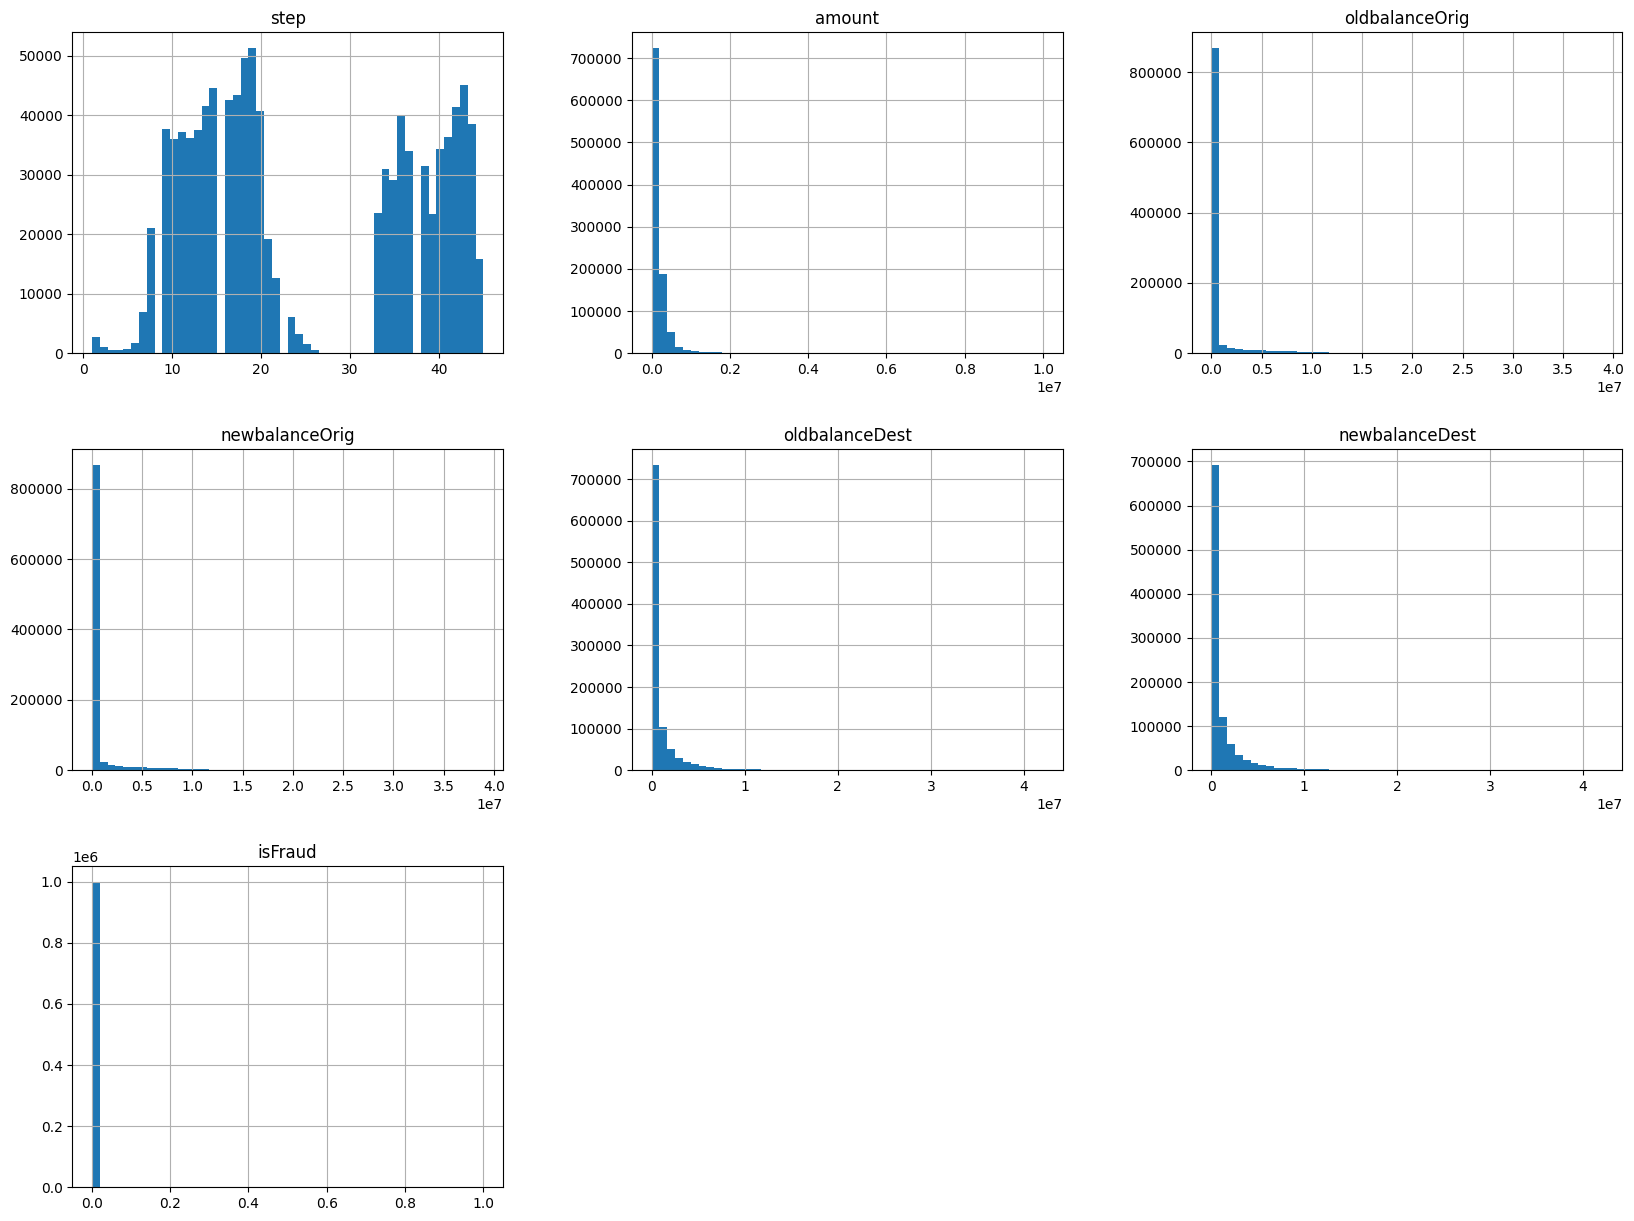

In [12]:
#Plotting a histrogram so as to clearly see if there is a posibiliy of an outlier
#housing.hist(bins=50, figsize=(20,15))
trans.hist(bins=50, figsize=(20,15))
plt.show() 

##  Looking at the data we clearly see

## DEALING WITH OUTLIERS

In [13]:
## AFTER DEALING WITH OUTLIERS

In [14]:
x=trans.drop("isFraud",axis=1)
y=trans["isFraud"]

#Separating the data for the target and the classes

In [15]:
x.info()
# looking at the info the type name origin and the name Dest are non numerical  but wait we forgoy one thing   that is to check if our dataset has missing values also

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            999999 non-null  int64  
 1   type            999999 non-null  object 
 2   amount          999984 non-null  float64
 3   nameOrig        999999 non-null  object 
 4   oldbalanceOrig  999999 non-null  float64
 5   newbalanceOrig  999999 non-null  float64
 6   nameDest        999999 non-null  object 
 7   oldbalanceDest  999999 non-null  float64
 8   newbalanceDest  999999 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 68.7+ MB


In [16]:
x.isnull().sum()
#looking at thedataset its only the amount that has the missing values

step               0
type               0
amount            15
nameOrig           0
oldbalanceOrig     0
newbalanceOrig     0
nameDest           0
oldbalanceDest     0
newbalanceDest     0
dtype: int64

In [17]:
# We are going to use median to fill the missing values
median = x["amount"].median()
x["amount"] = x["amount"].fillna(x["amount"].median())

In [18]:
# lets check again to see if there are no missing values
x.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrig    0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
dtype: int64

In [19]:
#now after making sure that the dataset is not empty the next step is to encode the categores but lets look at them again

x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            999999 non-null  int64  
 1   type            999999 non-null  object 
 2   amount          999999 non-null  float64
 3   nameOrig        999999 non-null  object 
 4   oldbalanceOrig  999999 non-null  float64
 5   newbalanceOrig  999999 non-null  float64
 6   nameDest        999999 non-null  object 
 7   oldbalanceDest  999999 non-null  float64
 8   newbalanceDest  999999 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 68.7+ MB


In [20]:
# lets initialize the label encoder which will help us convert the object types  into numerical
encoder=LabelEncoder()

In [21]:
# now lets encode all our data at once   
x["type"]=encoder.fit_transform(x["type"])
x['nameDest']=encoder.fit_transform(x["nameDest"])
x["nameOrig"]=encoder.fit_transform(x["nameOrig"])


In [22]:
#x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#splitting the data into test and train with 20% test  data and the rest  is train data  with a random state of 42
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
x_train.value_counts()  # looking at the data we have to encode the values so that we could put them in the models training   as we can seee  the name origin the type of type the name destination are non numerical

step  type  amount      nameOrig  oldbalanceOrig  newbalanceOrig  nameDest  oldbalanceDest  newbalanceDest
45    4     7335355.57  52841     7335355.57      0.00            80330     0.00            0.00              1
1     0     270.78      802848    4184966.65      4185237.43      87182     3019.00         0.00              1
            484.57      443735    5422437.76      5422922.33      76460     5638778.53      5579568.65        1
            783.31      302688    8150331.93      8151115.24      58574     2013.12         1229.81           1
            863.08      286331    9290756.54      9291619.62      71802     5577.88         4714.80           1
                                                                                                             ..
            9577.45     272301    519812.39       529389.85       85412     32204.00        22774.25          1
            9467.87     466186    6071.00         15538.87        62894     0.00            0.00             

In [24]:
y_train.value_counts()
#in this target all the values are numerical

isFraud
0    799572
1       427
Name: count, dtype: int64

In [25]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            999999 non-null  int64  
 1   type            999999 non-null  int64  
 2   amount          999999 non-null  float64
 3   nameOrig        999999 non-null  int64  
 4   oldbalanceOrig  999999 non-null  float64
 5   newbalanceOrig  999999 non-null  float64
 6   nameDest        999999 non-null  int64  
 7   oldbalanceDest  999999 non-null  float64
 8   newbalanceDest  999999 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 68.7 MB


In [26]:
model=SGDClassifier(random_state=42)
# initialized the linear model with a random state of 42 the meaning of life
#his clas‐sifier has the advantage of being capable of handling very large datasets efficiently.
#This is in part because SGD deals with training instances independently, one at a time

In [27]:
x.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrig    0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
dtype: int64

In [28]:
model.fit(x_train,y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [29]:
#1 measuring perfomances
train_scores = cross_val_score(model, x_train, y_train, cv=3, scoring="accuracy")
test_scores = cross_val_score(model, x_test, y_test, cv=3, scoring="accuracy")

# 2. Print the results (Using mixed single and double quotes to avoid syntax errors)
print(f"Train Accuracy Folds: {train_scores}")
print(f"Train Mean Accuracy:  {train_scores.mean():}")

print(f"Test Accuracy Folds:  {test_scores}")
print(f"Test Mean Accuracy:   {test_scores.mean():}")
#accuracy for the training data is 99

Train Accuracy Folds: [0.99893875 0.99959125 0.99955375]
Train Mean Accuracy:  0.9993612497296852
Test Accuracy Folds:  [0.999475 0.999565 0.99955 ]
Test Mean Accuracy:   0.999530000099977


In [30]:
prediction=model.predict(x_test)

In [31]:
#Out of all the predition flaggeed as fraud which is actually a fraud
#out of  all the fraud instances how many of them did it catch

print(f'PRECSION: {precision_score(y_test , prediction)}') 
print(f'RECALL: {recall_score(y_test, prediction)}')

PRECSION: 0.7627118644067796
RECALL: 0.4166666666666667


In [2]:
#LOOKING AT OUR DATA THIS MEANS THAT THE MODEL DOES HAVE A HIGHER CHANCE OF MOST OF ITS PREDCTION  TO BE  VERY HIGH  BUT HAS ALSO A ROW CHANCE OF CATCHIN THE ACTUALL FRAUD